# Fourier shapes: text data → neural spectrum → shape optimization

This notebook defines everything it uses, **except calls to the PDE solver**.
It needs Python with NumPy, SciPy, PyTorch, SymPy and Matplotlib.
If needed, install dependencies in your notebook environment with `%pip install numpy scipy torch sympy matplotlib`.
**The PDE solver needs the software [FreeFEM](https://freefem.org) to function.**

This notebook does not create new data. It relies on the two files `inputFourier_31.txt` and `dirichlet31.txt` present in the `data/` directory


In [ ]:
from pathlib import Path
import copy
import hashlib
import scipy
import time
import numpy as np
import matplotlib.pyplot as plt
import sympy as sp
import torch
from torch import nn
from scipy.spatial import cKDTree
import os

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.set_num_threads(2)
print("Device:", DEVICE)
if DEVICE.type == "cuda":
    print(torch.cuda.get_device_name(0))

# Directories
DATA_DIR = Path("data") if Path("data").is_dir() else Path("../data")
COEFFICIENT_FILE = DATA_DIR / "inputFourier_31.txt"
EIGENVALUE_FILE = DATA_DIR / "dirichlet31.txt"
PROJECT_DIR = DATA_DIR.resolve().parent
NOTEBOOK_DIR = PROJECT_DIR / "notebooks" if (PROJECT_DIR / "notebooks").is_dir() else PROJECT_DIR
OUTPUT_DIR = NOTEBOOK_DIR / "notebook_outputs"
OUTPUT_DIR.mkdir(exist_ok=True)

# Learned values
K = 10                        # Learn the consecutive eigenvalues 1,...,K (1 <= K <= 10).
TARGET_AREA = 1.0

# Networks parameters
MODEL_SEEDS = [100, 101, 102]
ACTFUNCS = [nn.ReLU, nn.SiLU, nn.Tanh]
ACTNAMES = ["relu", "silu", "tanh"]
WIDTHS   = [90, 192, 300]

CHECKPOINT_FILES = []
for act in range(len(ACTFUNCS)):
    CHECKPOINT_FILES.append([])
    for wid in range(len(WIDTHS)):
        CHECKPOINT_FILES[act].append(OUTPUT_DIR / (f"spectrum_ensemble_{WIDTHS[wid]}_" + ACTNAMES[act] + ".pt"))

# Training parameters
EPOCHS = 1200                 # Set to 5 for a quick check.
BATCH_SIZE = 256
LEARNING_RATE = 0.002
MIN_LEARNING_RATE = 2e-5
WEIGHT_DECAY = 1e-5
SPLIT_SEED = 20260909
RHO = 0.75                   # Certifies r(theta) >= 0.25*a0 > 0.

# Optimization parameters
OPTIMIZATION_STEPS = 500
NUMBER_OF_STARTS = 10
START_SEED = 41

# Reuse saved work by default. Change these only if you want a fresh computation.
FORCE_RETRAIN = False
REBUILD_SUPPORT = False

# Fail safe
assert 1 <= K <= 10 and EPOCHS >= 1 and BATCH_SIZE >= 1
assert TARGET_AREA > 0 and 0 < RHO < 1
assert NUMBER_OF_STARTS >= 1 and OPTIMIZATION_STEPS >= 0
    


Device: cpu


## 1. Load the text data

Rows correspond between files. The coefficient order is
$[a_0,a_1,\ldots,a_{15},b_1,\ldots,b_{15}]$, with
$$
r(\theta)=a_0+\sum_{j=1}^{15}(a_j\cos j\theta+b_j\sin j\theta).
$$
The eigenvalue file has ten numeric columns, in increasing index order, preceded by a comment header.
Both files use semicolons;

Remove scale from the inputs: $q=(a_1,\ldots,a_{15},b_1,\ldots,b_{15})/a_0$.
Compute analytic area $A=\pi[a_0^2+\frac12\sum(a_j^2+b_j^2)]$ and learn $J_k=A\lambda_k$.

In [ ]:
coefficients = np.loadtxt(COEFFICIENT_FILE, delimiter=";", comments="#", ndmin=2)
eigenvalues = np.loadtxt(EIGENVALUE_FILE, delimiter=";", comments="#", ndmin=2)

M = 15
q = coefficients[:, 1:] / coefficients[:, :1]
areas = np.pi * (coefficients[:, 0]**2 + 0.5 * (coefficients[:, 1:]**2).sum(axis=1))
J = areas[:, None] * eigenvalues[:, :K]


print(f"{len(q):,} shapes; {coefficients.shape[1]} physical coefficients; {q.shape[1]} inputs; {K} targets")

# New checkpoints record the exact two input files for compatibility checks.
data_fingerprint = hashlib.sha256(
    COEFFICIENT_FILE.read_bytes() + EIGENVALUE_FILE.read_bytes()).hexdigest()


20,000 shapes; 31 physical coefficients; 30 inputs; 10 targets


## 2. Train / validation / test split and normalization

The fixed 70% / 15% / 15% split gives **14,000 training, 3,000 validation and 3,000 test shapes**.
Training rows determine both the fitted weights and normalization constants. Validation selects each member's
checkpoint and later calibrates the geometric support restriction. Test rows evaluate the selected ensemble;
they do not determine the normalization or checkpoint.

**Why normalize?** Low Fourier modes have by design larger coefficients than high modes. Without scaling,
the network would see inputs of very different magnitudes. Recall that
$q=(u_1,\ldots,u_{15},v_1,\ldots,v_{15})$, where $u_j=a_j/a_0$ and $v_j=b_j/a_0$.
There is no input centering. For each harmonic, compute one common scale from the $N$ training rows:

$$
s_j=s_{15+j}=\max\left(\sqrt{\frac{1}{2N}\sum_{n=1}^{N}
\left(u_{nj}^{2}+v_{nj}^{2}\right)},\;10^{-6}\right),\qquad j=1,\ldots,15.
$$

Both coordinates of a harmonic pair are divided by the same number: $(u_j,v_j)\mapsto(u_j/s_j,v_j/s_j)$.
This rescales the pair without changing its direction.

A rotation by $\phi$ mixes that harmonic's cosine and sine coefficients through an orthogonal matrix:

$$
\begin{pmatrix}u'_j\\v'_j\end{pmatrix}
=
\begin{pmatrix}\cos(j\phi)&-\sin(j\phi)\\\sin(j\phi)&\cos(j\phi)\end{pmatrix}
\begin{pmatrix}u_j\\v_j\end{pmatrix}.
$$

The quantity $u_j^2+v_j^2$ is unchanged. Dividing both coordinates by the same $s_j$ commutes with this
rotation: **normalize then rotate gives the same coordinates as rotate then normalize**.
Separate scales for cosine and sine would generally break this property. This preserves symmetry in the
preprocessing.

**Targets and loss.** We learn the scale-invariant quantities $J_k=A\lambda_k>0$, using
$z_{nk}=\log J_{nk}$. Compute training-only means $\mu_k$ and sample standard deviations $\sigma_k$.
If $h_\theta(q/s)_k$ is the network's raw output, its decoded log prediction is

$$
\ell_{\theta,k}(q)=\mu_k+\sigma_k h_\theta(q/s)_k.
$$

The actual mini-batch loss in `training_loss` is

$$
\mathcal L_B(\theta)=\frac{1}{|B|K}\sum_{n\in B}\sum_{k=1}^{K}
\left[\frac{\ell_{\theta,k}(\widetilde q_n)-\log J_{nk}}{\sigma_k}\right]^2.
$$

Here $\widetilde q_n$ is a randomly rotated/reflected version of training shape $q_n$; its eigenvalues are
unchanged.
The scales stop targets with larger log variation from dominating the loss.

## 3. The network and symmetry averaging
For each couple (activation, width), each member has three hidden with the activation after each hidden layer, and a final affine layer:

$$
30\;\longrightarrow\;\text{width}\;\longrightarrow\;\text{width}\;\longrightarrow\;\text{width}\;\longrightarrow\;K.
$$

Three independent members are trained with seeds 100, 101 and 102.

For $K=10$ and $\text{width} = 192$, each has 81,994 trainable parameters. The raw network output represents standardized log $J$;
normalization and decoding are explicit in the functions below.

**Why the symmetry averaging?** Rotating or reflecting a domain leaves its Laplace eigenvalues unchanged,
but an ordinary network can assign slightly different predictions to these equivalent coefficient vectors.
We evaluate several equivalent versions of the same shape and combine their predictions.

For member $m$, let $\mathcal T$ contain 12 evenly spaced rotations and their reflected versions (24 views).
Its final prediction is

$$
\widehat J_k^{(m)}(q)=\exp\left[\frac{1}{24}\sum_{\tau\in\mathcal T}
\ell_{m,k}(\tau(q))\right].
$$

Next, combine the three independent members using an arithmetic mean:

$$
\widehat J_k(q)=\frac{1}{3}\sum_{m=1}^{3}\widehat J_k^{(m)}(q),
\qquad \widehat\lambda_k(q)=\frac{\widehat J_k(q)}{A_*}.
$$


Symmetry averaging uses the *same weights* on transformed inputs; ensemble averaging combines *independently
trained weights*. Autograd differentiates through both averages. Predictions remain positive, but their
ordering is not guaranteed; we do not sort them, since sorting would change which output gradient is used.

The next cells implement, in order, the split/scales, the network class and the prediction/loss functions.

In [83]:
indices = np.random.default_rng(SPLIT_SEED).permutation(len(q))
n_train, n_val = int(0.70 * len(q)), int(0.15 * len(q))
train_ids, val_ids, test_ids = np.split(indices, [n_train, n_train + n_val])
assert min(len(train_ids), len(val_ids), len(test_ids)) > 0

pair_scale = np.maximum(np.sqrt(np.mean(q[train_ids, :M]**2 + q[train_ids, M:]**2, axis=0) / 2), 1e-6)
x_scale = torch.tensor(np.tile(pair_scale, 2), dtype=torch.float32, device=DEVICE)
X_train = torch.tensor(q[train_ids], dtype=torch.float32, device=DEVICE)
X_val = torch.tensor(q[val_ids], dtype=torch.float32, device=DEVICE)
X_test = torch.tensor(q[test_ids], dtype=torch.float32, device=DEVICE)
Y_train = torch.tensor(np.log(J[train_ids]), dtype=torch.float32, device=DEVICE)
Y_val = torch.tensor(np.log(J[val_ids]), dtype=torch.float32, device=DEVICE)
y_mean = Y_train.mean(dim=0)
y_scale = Y_train.std(dim=0)  # Sample standard deviation.
assert bool((y_scale > 0).all())

np.savez(OUTPUT_DIR / "split.npz", train=train_ids, validation=val_ids, test=test_ids)
print("Train / validation / test:", len(train_ids), len(val_ids), len(test_ids))

Train / validation / test: 14000 3000 3000


In [90]:
torch.manual_seed(MODEL_SEEDS[0])

class SpectrumNet(nn.Module):
    def __init__(self, outputs, activation = nn.SiLU, width = 192):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(30, width), activation(),
            nn.Linear(width, width), activation(),
            nn.Linear(width, width), activation(),
            nn.Linear(width, outputs),
        )
    def forward(self, normalized_q):
        return self.layers(normalized_q)

print(SpectrumNet(K))
print("Parameters per member:", sum(p.numel() for p in SpectrumNet(K).parameters()))

def restore_checkpoint():
    """Restore all seed members and their preprocessing into this notebook session."""
    global x_scale, y_mean, y_scale
    global models, histories, member_records, trained_epochs, training_seconds, training_performed
    models, histories, member_records, trained_epochs, training_seconds, training_performed = [], [], [], [], [], []
    for act in range(len(ACTFUNCS)):
        models.append([]); histories.append([]); member_records.append([]); trained_epochs.append([]); training_seconds.append([]); training_performed.append([])        
        for wid in range(len(WIDTHS)):
            filepath = CHECKPOINT_FILES[act][wid]
            if not filepath.exists():
                raise RuntimeError("No saved ensemble found. Run Section 4 (load or train) first.")
            checkpoint = torch.load(filepath, map_location=DEVICE, weights_only=True)
            expected = {"K": K, "hidden_dim" : WIDTHS[wid], "activation" : ACTNAMES[act], "split_seed": SPLIT_SEED, "model_seeds": MODEL_SEEDS}
            for name, value in expected.items():
                if checkpoint.get(name) != value:
                    raise ValueError(f"Checkpoint {name} differs. Use another OUTPUT_DIR or set FORCE_RETRAIN=True.")
            if len(checkpoint["state_dicts"]) != len(MODEL_SEEDS):
                raise ValueError("Checkpoint ensemble size differs from MODEL_SEEDS.")
            if "data_fingerprint" in checkpoint and checkpoint["data_fingerprint"] != data_fingerprint:
                raise ValueError("Input files changed. Use another OUTPUT_DIR or set FORCE_RETRAIN=True.")
            x_scale = checkpoint["x_scale"].to(DEVICE)
            y_mean = checkpoint["y_mean"].to(DEVICE)
            y_scale = checkpoint["y_scale"].to(DEVICE)
            models[act].append([])
            for state in checkpoint["state_dicts"]:
                width = checkpoint["hidden_dim"]
                actName = checkpoint["activation"]
                act = ACTNAMES.index(actName)
                actFunc = ACTFUNCS[act]
                model = SpectrumNet(K, actFunc, width).to(DEVICE)
                model.load_state_dict(state)
                model.eval()
                model.requires_grad_(False)
                models[act][wid].append(model)
            member_records[act].append(checkpoint["members"])
            histories[act].append([np.asarray(h) for h in checkpoint.get("histories", [])])
            trained_epochs[act].append(checkpoint["epochs"])
            training_seconds[act].append(checkpoint.get("training_seconds", sum(r["seconds"] for r in member_records[act][wid])))
            print(f"Loaded {len(models[act][wid])} members trained for {trained_epochs[act][wid]} epochs with activation function " + ACTNAMES[act] +f" and width {WIDTHS[wid]}")
            training_performed[act].append(False)

def ensure_models():
    """Predictions need the complete ensemble, never just the last seed's model."""
    if not globals().get("models"):
        if FORCE_RETRAIN:
            raise RuntimeError("FORCE_RETRAIN=True: run Section 4 to train before prediction.")
        restore_checkpoint()
    if len(models) != len(MODEL_SEEDS):
        raise RuntimeError(f"Expected {len(MODEL_SEEDS)} seed models. Run Section 4 to load the complete ensemble.")


SpectrumNet(
  (layers): Sequential(
    (0): Linear(in_features=30, out_features=192, bias=True)
    (1): SiLU()
    (2): Linear(in_features=192, out_features=192, bias=True)
    (3): SiLU()
    (4): Linear(in_features=192, out_features=192, bias=True)
    (5): SiLU()
    (6): Linear(in_features=192, out_features=10, bias=True)
  )
)
Parameters per member: 81994


In [84]:
def rotate(points, angles):
    # points: (...,30); angles: scalar or compatible batch of rotation angles.
    frequencies = torch.arange(1, M + 1, dtype=points.dtype, device=points.device)
    phase = angles[..., None] * frequencies
    cosine, sine = phase.cos(), phase.sin()
    a, b = points[..., :M], points[..., M:]
    return torch.cat([a*cosine - b*sine, a*sine + b*cosine], dim=-1)

def log_prediction(model, points, rotations=12):
    reflection = points.new_tensor([1]*M + [-1]*M)
    views = []
    for i in range(rotations):
        view = rotate(points, points.new_tensor(2*np.pi*i/rotations))
        views.extend([view, view * reflection])
    standardized = model(torch.stack(views) / x_scale)
    return (standardized * y_scale + y_mean).mean(dim=0)

def predict_J(points, act, wid):
    ensure_models()
    # Models are independent; combine in physical J space, not log space.
    predictions = [log_prediction(model, points, rotations=12).exp() for model in models[act][wid]]
    return torch.stack(predictions).mean(dim=0)


def training_loss(model, augmented_q, log_J):
    # Keep the arithmetic order of the retained training implementation.
    predicted_log_J = model(augmented_q / x_scale) * y_scale + y_mean
    return (((predicted_log_J - log_J) / y_scale)**2).mean()

## 4. Training

AdamW: learning rate 0.002, weight decay $10^{-5}$, betas (0.9, 0.999), epsilon $10^{-8}$.
Cosine decay reaches $2\cdot10^{-5}$ after the chosen epoch budget. Each mini-batch receives new
uniform rotations and random reflections. Validation uses four rotations and their reflections.
Save the lowest-validation-loss weights, while running the whole epoch budget. There are no derivative labels.

This notebook trains the same three-member architecture as the retained ensemble. CUDA is used when available; otherwise every operation runs on CPU.
Changing `EPOCHS` also changes the cosine schedule, so a short run is a smoke check, not the beginning of the full schedule.

**Load or train.** The cell first looks for `CHECKPOINT_FILES`. A compatible file supplies both weights
and their saved normalization; the training loop is skipped. If no file exists, the ordinary training loop
runs and saves the result immediately. To intentionally retrain, use a new
`OUTPUT_DIR` or set `FORCE_RETRAIN=True`. The evaluation cell never overwrites a loaded checkpoint.


In [91]:
models, histories, member_records, trained_epochs, training_seconds, training_performed = [], [], [], [], [], []

for act in range(3):
    models.append([]); histories.append([]); member_records.append([]); trained_epochs.append([]); training_seconds.append([]); training_performed.append([])        
    for wid in range(3):
        training_performed[act].append(FORCE_RETRAIN or not CHECKPOINT_FILES[act][wid].exists())
        if training_performed[act][wid]:
            print(f"training:   width : {WIDTHS[wid]}, activation : " + ACTNAMES[act])
            width = WIDTHS[wid]
            actFunc = ACTFUNCS[act]
            actName = ACTNAMES[act]
            models[act].append([]); histories[act].append([]); member_records[act].append([])
            training_started = time.perf_counter()
            for seed in MODEL_SEEDS:
                torch.manual_seed(seed)
                model = SpectrumNet(K,actFunc, width).to(DEVICE)
                optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE,
                                     weight_decay=WEIGHT_DECAY, betas=(0.9, 0.999), eps=1e-8)
                scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
                    optimizer, T_max=EPOCHS, eta_min=MIN_LEARNING_RATE)
                best_validation = float("inf")
                best_state, best_epoch = None, None
                history = []
                member_started = time.perf_counter()
                for epoch in range(EPOCHS):
                    model.train()
                    total_loss = 0.0
                    order = torch.randperm(len(X_train), device=DEVICE)
                    for ids in order.split(BATCH_SIZE):
                        angles = torch.rand(len(ids), device=DEVICE) * (2*np.pi)
                        xb = rotate(X_train[ids], angles)
                        signs = torch.where(torch.rand(len(ids), 1, device=DEVICE) < 0.5, -1.0, 1.0)
                        xb = torch.cat([xb[:, :M], xb[:, M:] * signs], dim=1)
                        loss = training_loss(model, xb, Y_train[ids])
                        optimizer.zero_grad()
                        loss.backward()
                        optimizer.step()
                        total_loss += loss.item() * len(ids)
                    scheduler.step()

                    model.eval()
                    with torch.no_grad():
                        # Retain the exp/log arithmetic used for the original checkpoint selection.
                        validation_log = log_prediction(model, X_val, rotations=4).exp().log()
                        validation_loss = (((validation_log - Y_val) / y_scale)**2).mean().item()
                    assert np.isfinite(validation_loss), "Training became nonfinite."
                    history.append([epoch + 1, total_loss / len(X_train), validation_loss])
                    if validation_loss < best_validation:
                        best_validation, best_epoch = validation_loss, epoch + 1
                        best_state = copy.deepcopy(model.state_dict())
                    if epoch == 0 or (epoch + 1) % 50 == 0 or epoch == EPOCHS - 1:
                        print(f"Seed {seed}, epoch {epoch+1:4d}: train={history[-1][1]:.5f}, val={validation_loss:.5f}")

                model.load_state_dict(best_state)
                model.eval()
                models[act][wid].append(model)
                histories[act][wid].append(np.asarray(history))
                member_records[act][wid].append({"seed": seed, "best_epoch": best_epoch,
                               "seconds": time.perf_counter() - member_started})
                print(f"Seed {seed}: restored epoch {best_epoch}")
            training_seconds[act].append(time.perf_counter() - training_started)
            print(f"Ensemble training elapsed {training_seconds[act][wid]:.1f} seconds")
            trained_epochs[act].append(EPOCHS)
            # Save immediately after training, before test plots or shape optimization.
            torch.save({"state_dicts": [{key: value.cpu() for key, value in model.state_dict().items()}
                                        for model in models[act][wid]],
                        "x_scale": x_scale.cpu(), "y_mean": y_mean.cpu(), "y_scale": y_scale.cpu(),
                        "K": K, "hidden_dim": width, "activation": actName,
                        "members": member_records[act][wid], "histories": [h.tolist() for h in histories[act][wid]],
                        "epochs": trained_epochs[act][wid], "split_seed": SPLIT_SEED, "model_seeds": MODEL_SEEDS,
                        "data_fingerprint": data_fingerprint, "training_seconds": training_seconds[act][wid]},
                        CHECKPOINT_FILES[act][wid])
            print("Saved", CHECKPOINT_FILES[act][wid])
restore_checkpoint()

Loaded 3 members trained for 1200 epochs with activation function relu and width 90
Loaded 3 members trained for 1200 epochs with activation function relu and width 192
Loaded 3 members trained for 1200 epochs with activation function relu and width 300
Loaded 3 members trained for 1200 epochs with activation function silu and width 90
Loaded 3 members trained for 1200 epochs with activation function silu and width 192
Loaded 3 members trained for 1200 epochs with activation function silu and width 300
Loaded 3 members trained for 1200 epochs with activation function tanh and width 90
Loaded 3 members trained for 1200 epochs with activation function tanh and width 192
Loaded 3 members trained for 1200 epochs with activation function tanh and width 300


tested activation function : relu, tested width : 90, training time : 556.2105796700016
index | mean error (%) | 95th percentile (%)
    1 |         0.1436 |              0.5511
    2 |         0.1680 |              0.6384
    3 |         0.2495 |              0.9958
    4 |         0.2287 |              0.7819
    5 |         0.2753 |              1.0128
    6 |         0.2853 |              1.1287
    7 |         0.3472 |              1.1933
    8 |         0.3783 |              1.3645
    9 |         0.3148 |              1.2541
   10 |         0.3732 |              1.4539
Test rows with a predicted eigenvalue ordering inversion: 0


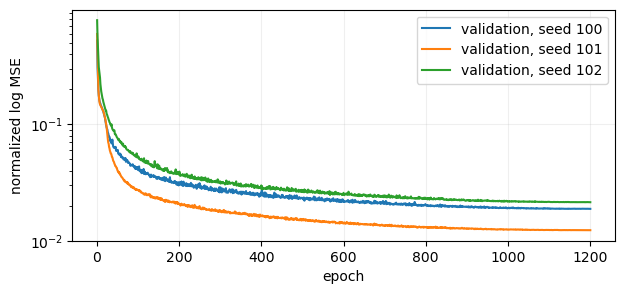

tested activation function : relu, tested width : 192, training time : 1087.188723094001
index | mean error (%) | 95th percentile (%)
    1 |         0.0892 |              0.3416
    2 |         0.0873 |              0.3442
    3 |         0.1304 |              0.5047
    4 |         0.1397 |              0.4754
    5 |         0.1728 |              0.6625
    6 |         0.1768 |              0.7508
    7 |         0.1875 |              0.6877
    8 |         0.2037 |              0.8229
    9 |         0.1942 |              0.8072
   10 |         0.2519 |              1.0134
Test rows with a predicted eigenvalue ordering inversion: 0


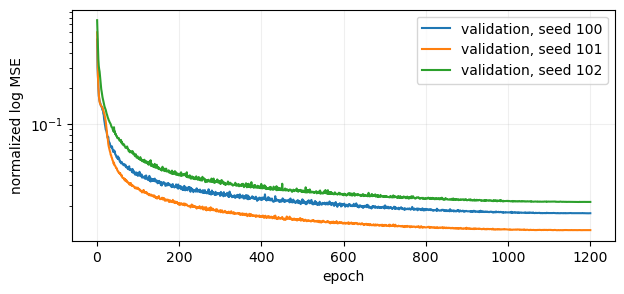

tested activation function : relu, tested width : 300, training time : 1684.5768864160018
index | mean error (%) | 95th percentile (%)
    1 |         0.0728 |              0.2794
    2 |         0.0706 |              0.2692
    3 |         0.1000 |              0.3833
    4 |         0.1190 |              0.4255
    5 |         0.1496 |              0.5750
    6 |         0.1554 |              0.6608
    7 |         0.1507 |              0.5961
    8 |         0.1656 |              0.6806
    9 |         0.1693 |              0.7208
   10 |         0.2233 |              0.9047
Test rows with a predicted eigenvalue ordering inversion: 0


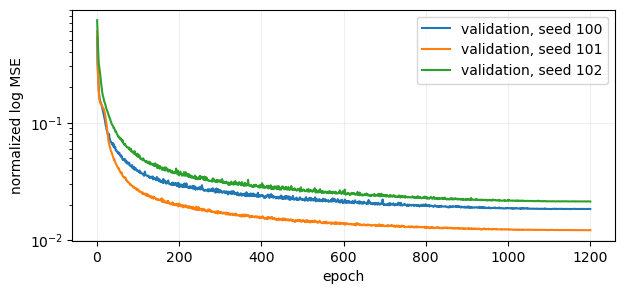

tested activation function : silu, tested width : 90, training time : 542.7798648829994
index | mean error (%) | 95th percentile (%)
    1 |         0.0992 |              0.3845
    2 |         0.1316 |              0.4296
    3 |         0.1797 |              0.6162
    4 |         0.2159 |              0.6767
    5 |         0.2623 |              0.8784
    6 |         0.2255 |              0.9299
    7 |         0.2769 |              0.9148
    8 |         0.3141 |              1.0867
    9 |         0.2756 |              1.0479
   10 |         0.3391 |              1.2098
Test rows with a predicted eigenvalue ordering inversion: 0


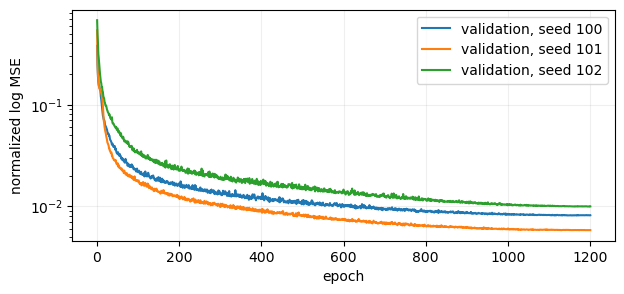

tested activation function : silu, tested width : 192, training time : 1002.113992159997
index | mean error (%) | 95th percentile (%)
    1 |         0.0541 |              0.2300
    2 |         0.0716 |              0.2524
    3 |         0.0964 |              0.3527
    4 |         0.1284 |              0.4027
    5 |         0.1540 |              0.5377
    6 |         0.1470 |              0.6474
    7 |         0.1720 |              0.5983
    8 |         0.1895 |              0.7129
    9 |         0.1839 |              0.7446
   10 |         0.2367 |              0.9173
Test rows with a predicted eigenvalue ordering inversion: 0


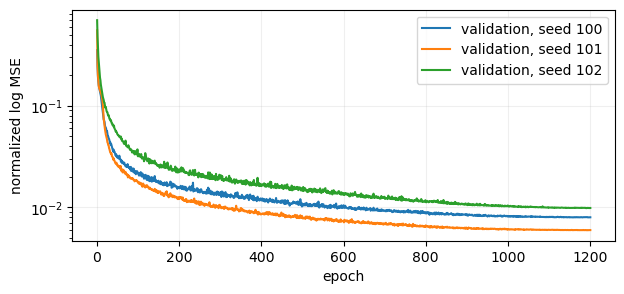

tested activation function : silu, tested width : 300, training time : 1716.2145284600047
index | mean error (%) | 95th percentile (%)
    1 |         0.0443 |              0.1894
    2 |         0.0542 |              0.2014
    3 |         0.0748 |              0.2659
    4 |         0.1044 |              0.3362
    5 |         0.1210 |              0.4360
    6 |         0.1178 |              0.5340
    7 |         0.1425 |              0.5104
    8 |         0.1526 |              0.5683
    9 |         0.1569 |              0.6686
   10 |         0.1980 |              0.7496
Test rows with a predicted eigenvalue ordering inversion: 0


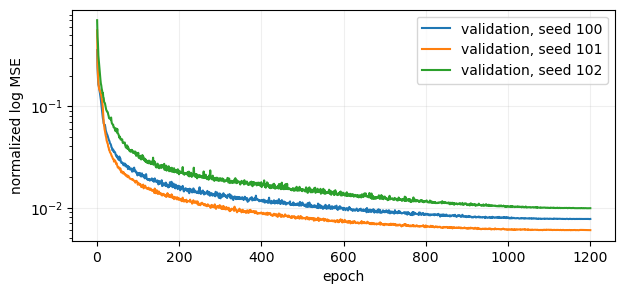

tested activation function : tanh, tested width : 90, training time : 582.4914469989963
index | mean error (%) | 95th percentile (%)
    1 |         0.1466 |              0.5475
    2 |         0.2174 |              0.6795
    3 |         0.3012 |              1.0217
    4 |         0.2772 |              0.8633
    5 |         0.3252 |              1.1167
    6 |         0.3276 |              1.2922
    7 |         0.3985 |              1.3418
    8 |         0.4295 |              1.4994
    9 |         0.3711 |              1.3810
   10 |         0.4724 |              1.6702
Test rows with a predicted eigenvalue ordering inversion: 0


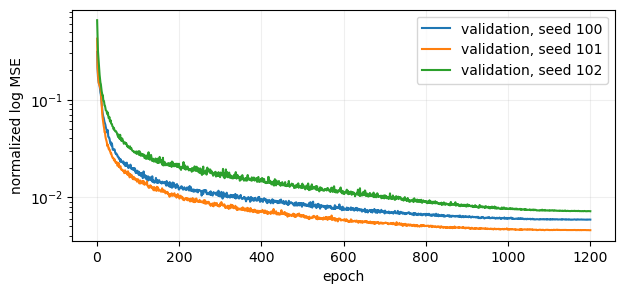

tested activation function : tanh, tested width : 192, training time : 997.5959053260012
index | mean error (%) | 95th percentile (%)
    1 |         0.0971 |              0.3909
    2 |         0.1125 |              0.4001
    3 |         0.1697 |              0.6392
    4 |         0.1876 |              0.5969
    5 |         0.2235 |              0.7881
    6 |         0.2212 |              0.9156
    7 |         0.2439 |              0.8381
    8 |         0.2644 |              0.9450
    9 |         0.2419 |              0.9619
   10 |         0.3076 |              1.1433
Test rows with a predicted eigenvalue ordering inversion: 0


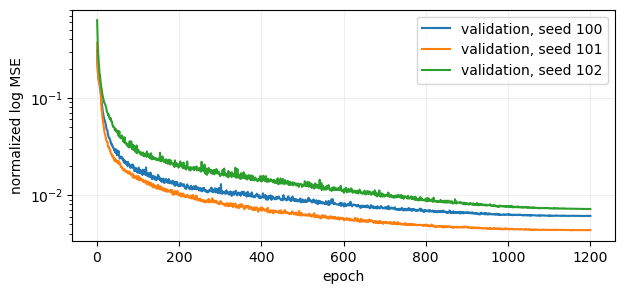

tested activation function : tanh, tested width : 300, training time : 1795.8019745220008
index | mean error (%) | 95th percentile (%)
    1 |         0.0858 |              0.3292
    2 |         0.0893 |              0.3280
    3 |         0.1343 |              0.5268
    4 |         0.1586 |              0.5194
    5 |         0.1825 |              0.6661
    6 |         0.1842 |              0.7315
    7 |         0.1889 |              0.6843
    8 |         0.2004 |              0.7591
    9 |         0.1945 |              0.8021
   10 |         0.2557 |              1.0037
Test rows with a predicted eigenvalue ordering inversion: 0


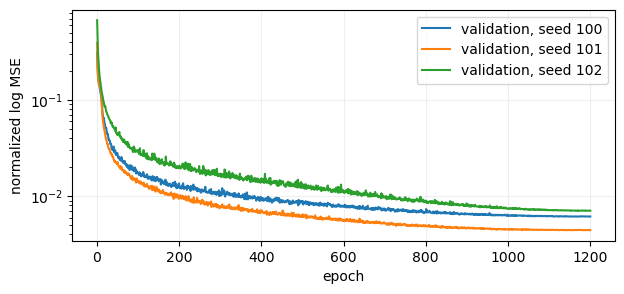

In [93]:
# Evaluate the selected checkpoint once on the test set.
for act in range(len(ACTFUNCS)):
    for wid in range(len(WIDTHS)):
        print(f"tested activation function : " + ACTNAMES[act] + f", tested width : {WIDTHS[wid]}, training time : {training_seconds[act][wid]}")
        with torch.no_grad():
            test_prediction = predict_J(X_test, act, wid).cpu().numpy()
        relative_error = np.abs(test_prediction / J[test_ids] - 1)
        print("index | mean error (%) | 95th percentile (%)")
        for column in range(K):
            print(f"{column+1:5d} | {100*relative_error[:, column].mean():14.4f} | "
                  f"{100*np.quantile(relative_error[:, column], 0.95):19.4f}")
        print("Test rows with a predicted eigenvalue ordering inversion:",
             np.any(np.diff(test_prediction, axis=1) < 0, axis=1).sum())

        if histories[act][wid]:
            plt.figure(figsize=(7, 3))
            for seed, history in zip(MODEL_SEEDS, histories):
                plt.semilogy(history[act][wid][:, 0], history[act][wid][:, 2], label=f"validation, seed {seed}")
            plt.xlabel("epoch"); plt.ylabel("normalized log MSE"); plt.legend(); plt.grid(alpha=0.2)
            plt.show()
        else:
            print("This older checkpoint did not save training curves; weights are ready for use.")

        # Freeze weights for shape search. Do not use torch.no_grad() around input gradients.
        for model in models[act][wid]:
            for parameter in model.parameters():
                parameter.requires_grad_(False)


## 5. Geometry: exact area and no self-intersection

At target area $A_*$, use $a_0=\sqrt{A_*/[\pi(1+\|q\|^2/2)]}$ and coefficients $a_0(1,q)$.
Projection changes harmonic amplitudes, preserving their phases. With metric weights $d_j>0$,
it minimizes $\sum_j\|q_j-\widetilde q_j\|^2/d_j$, using amplitudes
$\min(c_j,\max(h_j-\tau d_j,0))$. Bisection finds the active multiplier $\tau$.

In [ ]:
CAPS = np.full(M, RHO)
CAPS[3:] = 0.1 * (3 / np.arange(4, M + 1))**2

def amplitudes(points):
    return np.hypot(points[..., :M], points[..., M:])


def project(point, metric=None):
    point = np.asarray(point, dtype=float)
    weights = np.ones(M) if metric is None else np.asarray(metric)
    old = amplitudes(point)
    new = np.minimum(old, CAPS)
    if new.sum() > RHO:
        lo, hi = 0.0, np.max(old / weights)
        for _ in range(60):
            tau = (lo + hi) / 2
            new = np.minimum(CAPS, np.maximum(old - tau*weights, 0))
            if new.sum() > RHO:
                lo = tau
            else:
                hi = tau
        new = np.minimum(CAPS, np.maximum(old - hi*weights, 0))
    return point * np.tile(new / np.maximum(old, 1e-30), 2)


def physical_coefficients(point, target_area=TARGET_AREA):
    point = np.asarray(point)
    a0 = np.sqrt(target_area / (np.pi * (1 + 0.5*np.dot(point, point))))
    return a0 * np.r_[1.0, point]

def boundary_xy(point):
    c = physical_coefficients(point)
    theta = np.linspace(0, 2*np.pi, 721)
    phase = np.arange(1, M + 1)[:, None] * theta
    radius = c[0] + c[1:M+1] @ np.cos(phase) + c[M+1:] @ np.sin(phase)
    return radius*np.cos(theta), radius*np.sin(theta)

def boundary_xyPHYS(c):
    theta = np.linspace(0, 2*np.pi, 721)
    phase = np.arange(1, M + 1)[:, None] * theta
    radius = c[0] + c[1:M+1] @ np.cos(phase) + c[M+1:] @ np.sin(phase)
    return radius*np.cos(theta), radius*np.sin(theta)

## 6. Support restriction and projected descent

This section has two safeguards with different purposes: **support restriction limits extrapolation;
projection guarantees admissible geometry**. Neither proves that the predicted eigenvalues are accurate.

### Support restriction: stay near familiar shapes

A gradient optimizer can exploit network errors by moving to unfamiliar shapes with artificially low
predicted eigenvalues. Build a KD tree containing the **14,000 training shapes plus the disk**, each in
24 rotations and both reflections: **672,048 coefficient vectors**. These are symmetry copies of existing
shapes, not new PDE labels. Let this set be $\mathcal T$. Distances use componentwise input normalization:

$$
d(q)=\min_{p\in\mathcal T}\left\|(q-p)/s\right\|_2.
$$

Using $s$ makes distance sensitive to changes relative to each mode's typical training amplitude.
A KD tree accelerates the nearest-neighbor query; it does not evaluate the network or solve a PDE.
Evaluate $d(q)$ for the 3,000 validation shapes, then set

$$
R=\max\left(0.08,\;1.5\,Q_{0.95}\{d(q):q\text{ is a validation shape}\}\right).
$$

A proposed iterate must satisfy $d(q)\leq R$. For the supplied dataset this gives
$R\approx10.7399474$ in normalized coefficient coordinates, not physical length units.
The 95th percentile and factor 1.5 are heuristic choices, not confidence bounds. The accepted region is a
union of neighborhoods of training shapes; being inside it does not certify interpolation accuracy.
Validation **geometry**, not validation eigenvalue labels, calibrates this restriction.

### Projected descent: improve the objective without violating geometry

`minimize_from(start, value_gradient)` receives an initial coefficient vector and a callback returning
$f(q)$ and its input gradient $g=\nabla_q f(q)$. Network weights stay frozen.
Let $C$ denote the amplitude-budget/cap constraints from Section 5. An iteration performs:

1. **Precondition the gradient.** Use the positive diagonal matrix
   $D_{ii}=[s_i/\operatorname{median}(s_1,s_2,s_3)]^2$ to adjust updates across differently scaled Fourier modes.
   Form $u=\eta Dg$ and shrink it if necessary so that $\|u\|_2\leq0.06$.
2. **Project the proposal.** Compute $q'=P_C^{D^{-1}}(q-u)$, the point in $C$ closest to $q-u$ in the
   weighted squared distance $\sum_i (q'_i-(q_i-u_i))^2/D_{ii}$.
   The `project` function preserves each harmonic's phase and adjusts its amplitude using the bisection
   formula in Section 5. This enforces the caps and $r(\theta)\geq0.25a_0>0$ for every angle.
3. **Check support.** Reject $q'$ if $d(q')>R$. We reject an unsupported proposal rather than project it
   onto the generally nonconvex support region.
4. **Check sufficient decrease.** Require the Armijo inequality

$$
f(q')\leq f(q)+10^{-4}g^{\mathsf T}(q'-q).
$$

The gradient predicts how much the objective should decrease along the actual *projected* displacement.
The Armijo test requires a small fraction of that predicted decrease. If a check fails, halve $\eta$ and retry,
up to 18 backtracks. An undefined symbolic objective also rejects the trial. Start with $\eta=0.2$;
after an accepted step increase it by 1.3, capped at 3. Only accepted objective values enter `trace`.
The trace also includes the initial value, so accepted progress can be compared with its starting shape.

Stop at the iteration budget, failed backtracking, $\eta<10^{-8}$, or

$$
\left\|q-P_C\big(q-\nabla f(q)\big)\right\|_2<2\cdot10^{-5}.
$$

This last diagnostic uses **Euclidean** projection onto $C$; it measures approximate stationarity for the
coefficient constraints, not the support boundary. None of the stopping reasons certifies a global minimum.
Multiple starts help explore different local minima; candidates are ranked using the neural objective only.

The objective is supplied by the next sections: Section 7 minimizes $\log\widehat J_k$, while Section 8
minimizes a scaled spectral function. Exact area is imposed when converting $q$ to physical coefficients.

### Reusing the support computation

In the same kernel, the tree is kept in memory. After restarting the kernel, its construction is repeated
(typically a few seconds), while the expensive 3,000 validation distances are loaded from a small `.npz`
cache in `OUTPUT_DIR`. Their 95th percentile determines the radius as before. The complete large tree need
not be written to disk. The first uncached run still takes about three minutes.

The cache key includes training and validation coefficient arrays, input scales, rotation code and
PyTorch/SciPy versions. Changed data, split, scales or numerical construction trigger recalculation.
Changing the eigenvalue index, symbolic function or target area does **not**: the tree describes normalized
shape coefficients, independently of the chosen objective. Retraining with unchanged inputs/scales can reuse
it too. Set `REBUILD_SUPPORT=True` to explicitly rebuild and recalibrate once, then return it to `False`.


In [94]:
support_started = time.perf_counter()
ensure_models()  # Restore all saved models and members if Section 4 was skipped.
support_scale = x_scale.detach().cpu().numpy().astype(float)

# The key depends on geometry, split, scales and the numerical construction, not on F or k.
digest = hashlib.sha256(b"support-v1:24-rotations:reflection:float32:q95*1.5:floor0.08")
digest.update((str(torch.__version__) + scipy.__version__).encode())
digest.update(rotate.__code__.co_code)
digest.update(repr(rotate.__code__.co_consts).encode())
for array in [q[train_ids], q[val_ids], support_scale]:
    digest.update(str((array.shape, array.dtype)).encode())
    digest.update(np.ascontiguousarray(array).tobytes())
support_key = digest.hexdigest()
calibration_file = OUTPUT_DIR / f"support_calibration_{support_key[:20]}.npz"

if REBUILD_SUPPORT or globals().get("support_cache_key") != support_key:
    # Cheap tree build (typically seconds); expensive radius calibration is cached below.
    support_base = torch.tensor(np.vstack([q[train_ids], np.zeros(30)]), dtype=torch.float32)
    views = []
    for angle in np.arange(24) * 2*np.pi/24:
        view = rotate(support_base, support_base.new_tensor(angle)).numpy()
        views.extend([view, view * np.array([1]*M + [-1]*M)])
    support_tree = cKDTree(np.concatenate(views) / support_scale)
    del views, support_base
    support_cache_key = support_key
    print("Support tree built.")
else:
    print("Reusing the support tree in this kernel.")

calibration_loaded = False
if calibration_file.exists() and not REBUILD_SUPPORT:
    try:
        with np.load(calibration_file, allow_pickle=False) as saved:
            validation_distances = saved["distances"].copy()
            if str(saved["key"]) != support_key or validation_distances.shape != (len(val_ids),):
                raise ValueError("Calibration cache does not match.")
            if not np.isfinite(validation_distances).all() or (validation_distances < 0).any():
                raise ValueError("Invalid cached distances.")
        calibration_loaded = True
        print("Loaded support calibration from", calibration_file.name)
    except (OSError, ValueError, KeyError):
        print("Calibration cache is unreadable; recalculating.")
if not calibration_loaded:
    print("Calibrating validation distances (CPU; usually a few minutes)...")
    validation_distances = support_tree.query(q[val_ids] / support_scale)[0]
    np.savez(calibration_file, key=support_key, distances=validation_distances)
    print("Saved support calibration.")
SUPPORT_RADIUS = max(0.08, 1.5 * np.quantile(validation_distances, 0.95))
preconditioner = (support_scale / np.median(support_scale[:3]))**2
print(f"Support radius: {SUPPORT_RADIUS:.9f}; setup: {time.perf_counter()-support_started:.2f} s")


def minimize_from(start, value_gradient, act, wid, steps):
    point = project(start)
    value, gradient = value_gradient(point, act, wid)
    trace = [value]
    step = 0.2
    reason = "iteration budget"
    for iteration in range(steps):
        stationarity = np.linalg.norm(point - project(point - gradient))
        if stationarity < 2e-5:
            reason = f"projected gradient tolerance, stopped at iteration {iteration}"
            break
        accepted = False
        for _ in range(18):
            displacement = step * preconditioner * gradient
            displacement *= min(1.0, 0.06 / max(np.linalg.norm(displacement), 1e-20))
            proposal = project(point - displacement, preconditioner[:M])
            delta = proposal - point
            supported = support_tree.query(proposal / support_scale)[0] <= SUPPORT_RADIUS
            if supported:
                try:
                    new_value, new_gradient = value_gradient(proposal, act, wid)
                except FloatingPointError:  # E.g. log or sqrt outside the functional's domain.
                    new_value = np.inf
                if new_value <= value + 1e-4*np.dot(gradient, delta):
                    point, value, gradient = proposal, new_value, new_gradient
                    trace.append(value)
                    step = min(1.3*step, 3.0)
                    accepted = True
                    break
            step *= 0.5
        if not accepted or step < 1e-8:
            reason = f"line search / support / tiny step, stopped at iteration {iteration}"
            break

    return {"q": point, "value": value, "trace": np.array(trace), "reason": reason}


def search(starts, value_gradient, act, wid, steps = OPTIMIZATION_STEPS):
    runs = []
    for i, start in enumerate(starts):
        try:
            run = minimize_from(start, value_gradient, act, wid, steps)
        except FloatingPointError:
            print(f"Start {i}: function undefined at initial predicted spectrum; skipped")
            continue
        runs.append(run)
        print(f"Start {i}: objective {run['trace'][0]:.6f} -> {run['value']:.6f}; {run['reason']}")
    if not runs:
        raise ValueError("No valid starts for this functional.")
    return min(runs, key=lambda run: run["value"]), runs

Reusing the support tree in this kernel.
Loaded support calibration from support_calibration_12aed890bc8af5b5f1c4.npz
Support radius: 10.739947417; setup: 0.01 s


## 7. Optimize one eigenvalue

The line search minimizes
$f(q)=\log\widehat J_k(q)$. The stored `trace` and `value` remain logarithms.

The FreeFEM script is called a posteriori to compute the spectrum of the selected shape independently of the chosen model


In [ ]:
# Generation of the initial shapes : the disk, the 4 best shapes for lambdak, 5 random shapes in the rest of training data
disk = np.zeros(30)
rng = np.random.default_rng(START_SEED)

starts = []
for k in range(10):
    starts.append([])
    starts[k].append(disk)
    best_rows = train_ids[np.argsort(J[train_ids, k])]
    starts[k].extend(q[best_rows[:4]])
    starts[k].extend(q[best_rows[rng.choice(len(train_ids)-4, max(0, NUMBER_OF_STARTS - len(starts[k])), replace=False) + 4]])

# Totally random start among the training data
startsRandom = q[train_ids[rng.choice(len(train_ids), 10, replace=False)]]

In [ ]:
# FreeFEM calls
def ComputeFreeFEMSpectrum(q):
    c = physical_coefficients(q)
    with open("input.txt", 'w') as f:
        f.write(f"{15} {640} {10}\n")
        np.savetxt(f, c, fmt='%1.16f', delimiter='; ',newline='\n')

    FourierScript = NOTEBOOK_DIR/"eigenvalues.edp"
    FourierScript = str(FourierScript)
    FourierScript = "FreeFem++ -ne " + FourierScript
    success = os.system(FourierScript)

    Spectrum = np.zeros(10)
    if success == 0: # Check that the freefem script succeeded
        with open("output.txt", 'r') as f : 
            i = 0
            for line in f:
                if i>0:
                    Spectrum[i-1] = float(line)
                i += 1

    os.system("rm input.txt output.txt") # Clean up
    
    return Spectrum

In [ ]:
def plotShape(shape, name, title = None):
    plt.figure()
    plt.plot(*boundary_xy(shape), color = "red")
    plt.axis("square")
    plt.xticks([])
    plt.yticks([])
    plt.tight_layout()
    if title: plt.title(title)
    namepdf =  name + ".pdf"
    plt.savefig(OUTPUT_DIR/ "shapes" / namepdf, format = 'pdf', bbox_inches = 'tight')
    plt.show()

def plotShapePHYS(shape, name, title = None):
    plt.figure()
    plt.plot(*boundary_xyPHYS(shape), color = "red")
    plt.axis("square")
    plt.xticks([])
    plt.yticks([])
    plt.tight_layout()
    if title: plt.title(title)
    namepdf =  name + ".pdf"
    plt.savefig(OUTPUT_DIR/ "shapes" / namepdf, format = 'pdf', bbox_inches = 'tight')
    plt.show()


In [ ]:
# Optimization of one eigenvalue with the ReLU network and the SiLU network of width 192
wid = 1
EIGENVALUE_INDEX = 10

k = EIGENVALUE_INDEX - 1

# Eigenvalue function 
def eigenvalue_value_gradient(point, act, wid):
    x = torch.tensor(point, dtype=torch.float32, device=DEVICE, requires_grad=True)
    value = predict_J(x, act, wid)[k].log()
    gradient = torch.autograd.grad(value, x)[0]
    if not bool(torch.isfinite(value)) or not bool(torch.isfinite(gradient).all()):
        raise FloatingPointError("Nonfinite eigenvalue objective or gradient")
    return value.item(), gradient.detach().cpu().numpy().astype(float)


print("relu")
act = 0
best_eigenvalueR, eigenvalue_runsR = search(starts[k], eigenvalue_value_gradient, act, wid)
with torch.no_grad():
    optimized_spectrumR = predict_J(torch.tensor(best_eigenvalueR["q"], dtype=torch.float32, device=DEVICE), act, wid).cpu().numpy() / TARGET_AREA
print(f"Predicted area × lambda_{k+1}: {TARGET_AREA * optimized_spectrumR[k]:.6f}")
print(f"Predicted lambda_{k+1} at area {TARGET_AREA}: {optimized_spectrumR[k]:.6f}")
print("Predicted spectrum:", optimized_spectrumR)

FFM_spectrumR = ComputeFreeFEMSpectrum(best_eigenvalueR["q"])
name = f"lambda{k+1}ReLU"
plotShape(best_eigenvalueR["q"], name)
np.savetxt(OUTPUT_DIR/ "coefficients"  / (name+".txt"), physical_coefficients(best_eigenvalueR["q"])[None, :], delimiter="; ")

print("silu")
act = 1
best_eigenvalueS, eigenvalue_runsS = search(starts[k], eigenvalue_value_gradient, act, wid)
with torch.no_grad():
    optimized_spectrumS = predict_J(torch.tensor(best_eigenvalueS["q"], dtype=torch.float32, device=DEVICE), act, wid).cpu().numpy() / TARGET_AREA
print(f"Predicted area × lambda_{k+1}: {TARGET_AREA * optimized_spectrumS[k]:.6f}")
print(f"Predicted lambda_{k+1} at area {TARGET_AREA}: {optimized_spectrumS[k]:.6f}")
print("Predicted spectrum:", optimized_spectrumS)

FFM_spectrumS = ComputeFreeFEMSpectrum(best_eigenvalueS["q"])
name = f"lambda{k+1}SiLU"
plotShape(best_eigenvalueS["q"], name)
np.savetxt(OUTPUT_DIR / "coefficients" / (name+".txt"), physical_coefficients(best_eigenvalueS["q"])[None, :], delimiter="; ")


## 8. Optimize a symbolic function of the predicted spectrum

Edit `F_expression` directly as a SymPy expression. Variables `x[0],...,x[K-1]` represent the
**physical** eigenvalues $\lambda_1,\ldots,\lambda_K$ at `TARGET_AREA`.
Examples: a weighted sum, a ratio, a polynomial, or `sp.log`/`sp.exp`/`sp.sqrt` compositions in their domains.
Use a $C^1$ function on the spectra explored. We check finite values and derivatives.

SymPy computes $\partial F/\partial\lambda_k$ symbolically. PyTorch supplies the spectral derivatives:
$$
\nabla_q F = \sum_{k=1}^{K}\frac{\partial F}{\partial\lambda_k}\nabla_q\widehat\lambda_k.
$$
The partial derivatives are passed as `grad_outputs` in a vector–Jacobian product.
We minimize $F/s_F$ (or $-F/s_F$ to maximize), using a fixed positive scale based on the disk;
**we do not take $\log F$**, so zero and negative function values are allowed.

In [ ]:
x = sp.symbols(f"x1:{K+1}", positive=True)
# Examples for K=10:
#F_expression = x[0] + x[1]
F_expression = x[5] / x[0]
#F_expression = (x[4] - x[5])**2 + sp.log(x[0])
#F_expression = x[1] -x[0]
#F_expression = x[1]/x[0]
#F_expression = x[2] + x[9]
#F_expression = x[1] + sp.cos(x[4] - x[0])
#F_expression = sum(x[i] for i in range(10))
MAXIMIZE = True

act, wid = 1, 1

assert F_expression.free_symbols <= set(x)
F_partials = [sp.diff(F_expression, variable) for variable in x]
F_numpy = sp.lambdify(x, F_expression, modules="numpy")
partials_numpy = sp.lambdify(x, F_partials, modules="numpy")
display(F_expression)
display(sp.Matrix(F_partials))


def function_and_partials(spectrum):
    with np.errstate(all="ignore"):
        value = float(F_numpy(*spectrum))
        partials = np.asarray(partials_numpy(*spectrum), dtype=float).reshape(K)
    if not np.isfinite(value) or not np.isfinite(partials).all():
        raise FloatingPointError("F or its derivatives are undefined at this spectrum")
    return value, partials


with torch.no_grad():
    disk_spectrum = predict_J(torch.zeros(30, device=DEVICE), act, wid).cpu().numpy() / TARGET_AREA
F_SCALE = max(1.0, abs(function_and_partials(disk_spectrum)[0]))
F_SIGN = -1.0 if MAXIMIZE else 1.0


def functional_value_gradient(point, act, wid):
    q_tensor = torch.tensor(point, dtype=torch.float32, device=DEVICE, requires_grad=True)
    spectrum = predict_J(q_tensor, act, wid) / TARGET_AREA
    raw_value, partials = function_and_partials(spectrum.detach().cpu().numpy())
    weights = torch.as_tensor(F_SIGN * partials / F_SCALE, dtype=spectrum.dtype, device=DEVICE)
    gradient = torch.autograd.grad(spectrum, q_tensor, grad_outputs=weights)[0]
    if not bool(torch.isfinite(gradient).all()):
        raise FloatingPointError("Nonfinite neural gradient")
    return F_SIGN * raw_value / F_SCALE, gradient.detach().cpu().numpy().astype(float)

In [ ]:
act, wid = 2, 1
best_function, functional_runs = search(startsRandom, functional_value_gradient, act, wid)
with torch.no_grad():
    final_spectrum = predict_J(torch.tensor(best_function["q"], dtype=torch.float32, device=DEVICE), act, wid).cpu().numpy() / TARGET_AREA
print("Predicted spectrum:", final_spectrum)
print("Unscaled F:", function_and_partials(final_spectrum)[0])
plotShape(best_function["q"], "Symbolic_spectral_functional")
np.savetxt(OUTPUT_DIR / "coefficients" / "functional_shape.txt", physical_coefficients(best_function["q"])[None, :], delimiter="; ")